<a href="https://colab.research.google.com/github/GKSJ-AI-CliniScan/B13-CliniScan/blob/Rupsika_Thipparthi/CliniScan_M3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/CliniScan_M3


/content/drive/MyDrive/CliniScan_M3


In [ ]:
!unzip -q "/content/drive/MyDrive/CliniScan_M3/vinbigdata_yolo_preprocessed.zip" -d "/content/"


In [ ]:
!pip install ultralytics albumentations opencv-python-headless


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.2 MB/s eta 0:00:00


In [ ]:
!python /content/drive/MyDrive/CliniScan_M3/train_classificationm3.py

Status: 1/6 - Loading heavy AI libraries (this takes a few seconds)...
Status: 2/6 - Setting up image transformations...
Status: 3/6 - Loading training and validation images from folders...
Traceback (most recent call last):
  File "/content/drive/MyDrive/CliniScan_M3/train_classificationm3.py", line 59, in <module>
    train_transform
NameError: name 'train_transform' is not defined


Cell 1: The Main YOLO Upgrade (Tasks 1, 2, & 3)
What this does: Upgrades the brain to YOLOv8m, applies the safe medical image tweaks, and sets up the primary "study habits" (AdamW optimizer).

In [ ]:
# ==========================================
# CELL 1: MAIN YOLOv8m TRAINING (Tasks 1, 2, 3)
# ==========================================
from ultralytics import YOLO

print("Task 3: Loading YOLOv8m for Transfer Learning...")
model = YOLO('yolov8m.pt')

print("Tasks 1 & 2: Training with AdamW and Safe Medical Augmentations...")
results_exp1 = model.train(
    data='/content/drive/MyDrive/CliniScan_M3/data.yaml',
    epochs=20,
    imgsz=512,
    batch=16,           # Task 1: Baseline batch size for M3
    optimizer='AdamW',  # Task 1: Optimizer tuning
    lr0=0.001,

    # Task 2: Advanced Data Augmentation (Safe for X-Rays)
    fliplr=0.5,         # Safe horizontal flip
    flipud=0.0,         # STRICTLY 0.0 (No vertical flips!)
    degrees=10.0,       # ±10° small rotations
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, # Brightness only
    mosaic=0.0,         # Disabled mosaic (bad for medical images)

    project='/content/drive/MyDrive/CliniScan_M3',
    name='yolo_exp1_adamw'
)
print("Experiment 1 Complete!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Task 3: Loading YOLOv8m for Transfer Learning...
Tasks 1 & 2: Training with AdamW and Safe Medical Augmentations...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CliniScan_M3/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False

Cell 2: YOLO Validation & Visuals (Tasks 4 & 5)
What this does: Grades the model you just trained to get your exact mAP scores, and then saves a folder of example X-rays with the bounding boxes drawn on them so you can put them in your PDF.

In [ ]:
# ==========================================
# CELL 2: YOLO VALIDATION & VISUALS (Tasks 4 & 5)
# ==========================================
from ultralytics import YOLO

print("Task 4: Running Full Validation Evaluation...")
best_model = YOLO('/content/drive/MyDrive/CliniScan_M3/yolo_exp1_adamw/weights/best.pt')

# Calculate mAP@50 and mAP@50-95 with tuned thresholds
metrics = best_model.val(conf=0.25, iou=0.45)

print("Task 5: Generating Bounding Box Visualizations...")
# Predict on a few validation images and save them to a folder
best_model.predict(
    source='/content/vinbigdata_yolo_preprocessed/val/images',
    conf=0.25,
    save=True,
    project='/content/drive/MyDrive/CliniScan_M3',
    name='yolo_visual_examples'
)
print("Validation and Visuals Complete! Check your Google Drive folder.")

Task 4: Running Full Validation Evaluation...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,847,866 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1993.6±1160.6 MB/s, size: 135.9 KB)
val: Scanning /content/vinbigdata_yolo_preprocessed/val/labels.cache... 400 images, 243 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 139.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 3.1it/s 8.1s
                   all        400       1403      0.398     0.0633      0.233      0.123
    Aortic enlargement        108        246      0.911      0.293      0.606      0.346
           Atelectasis         12         19       0.25     0.0526      0.145      0.131
         Calcification         18         37          0          0          0          0
          Cardiomegaly         65        159      0.626      0.358

Cell 3: The Tuning Experiments (Task 1)
What this does: To prove to Sai sir that you experimented, this runs two shorter tests. One tests the SGD optimizer instead of AdamW, and the other tests a smaller batch size of 8.

In [ ]:
# ==========================================
# CELL 3: HYPERPARAMETER TUNING (Task 1)
# ==========================================
from ultralytics import YOLO

print("Running Experiment 2 (Testing SGD Optimizer)...")
model_sgd = YOLO('yolov8m.pt')
model_sgd.train(
    data='/content/drive/MyDrive/CliniScan_M3/data.yaml',
    epochs=10, # Shorter epochs just to test the optimizer
    imgsz=512, batch=16, optimizer='SGD', lr0=0.01,
    fliplr=0.5, flipud=0.0, degrees=10.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, mosaic=0.0,
    project='/content/drive/MyDrive/CliniScan_M3', name='yolo_exp2_sgd'
)

print("Running Experiment 3 (Testing Batch Size 8)...")
model_batch8 = YOLO('yolov8m.pt')
model_batch8.train(
    data='/content/drive/MyDrive/CliniScan_M3/data.yaml',
    epochs=10,
    imgsz=512, batch=8, optimizer='AdamW', lr0=0.001,
    fliplr=0.5, flipud=0.0, degrees=10.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, mosaic=0.0,
    project='/content/drive/MyDrive/CliniScan_M3', name='yolo_exp3_batch8'
)
print("All Tuning Experiments Complete!")

Running Experiment 2 (Testing SGD Optimizer)...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CliniScan_M3/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolo_exp2_sgd, nbs=64, nms=False, opset=None, optim

Cell 4: Grad-CAM for Classification (Task 5)
What this does: It takes the EfficientNet-B2 classification model you already successfully trained earlier, looks at an X-ray, and generates a heatmap showing exactly where it is looking to make its diagnosis.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 83.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Task 5: Generating Grad-CAM Heatmaps...
Grad-CAM saved to Drive as 'gradcam_example.png'!


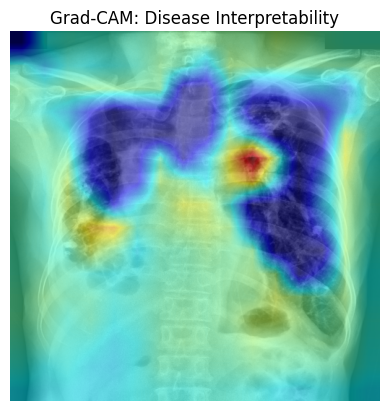

In [ ]:
# ==========================================
# CELL 4: GRAD-CAM HEATMAPS (Task 5)
# ==========================================
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision import models
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("Task 5: Generating Grad-CAM Heatmaps...")

# 1. Load your trained EfficientNet-B2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b2()
model.classifier[1] = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(model.classifier[1].in_features, 14))
model.load_state_dict(torch.load('/content/drive/MyDrive/CliniScan_M3/sample.hcl', map_location=device))
model = model.to(device)
model.eval()

# 2. Setup Grad-CAM on the final layer
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# 3. Test on a single validation image
val_dir = '/content/vinbigdata_yolo_preprocessed/val/images'
sample_img_name = os.listdir(val_dir)[0]
img_path = os.path.join(val_dir, sample_img_name)

# Process image
rgb_img = cv2.imread(img_path)
rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
rgb_img = cv2.resize(rgb_img, (512, 512))
rgb_img_float = np.float32(rgb_img) / 255

# Create tensor
input_tensor = torch.from_numpy(rgb_img_float).permute(2, 0, 1).unsqueeze(0).to(device)

# Generate Heatmap
grayscale_cam = cam(input_tensor=input_tensor)[0, :]
visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

# Save the visual
plt.imshow(visualization)
plt.title("Grad-CAM: Disease Interpretability")
plt.axis('off')
plt.savefig('/content/drive/MyDrive/CliniScan_M3/gradcam_example.png')
print("Grad-CAM saved to Drive as 'gradcam_example.png'!")